In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, recall_score, f1_score, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer


from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 123

In [2]:
cue_df = pd.read_csv("../results/Qwen3_VL_4B_Instruct_visual_cues_5s5fps_cropped_results.csv")
gt = pd.read_csv('../../labels_v2.csv', sep = ';')

cue_df

,subject,activity,window_id,head_movement,blink_behavior,eye_aperture,gaze_direction,gaze_stability,eyebrow_movement,mouth_shape,lip_pressing,lip_corner_tension,jaw_mouth_tension,visual_confidence,visual_summary
0,2ea4,Baseline,0,0,1,1,0,0,0,1,0,0,0,0.80,The subject maintains steady gaze with minimal...
1,2ea4,Baseline,1,0,1,1,0,0,0,1,0,0,0,0.85,Mild blinking and slight mouth tension are vis...
2,2ea4,Baseline,10,0,1,1,0,0,0,1,0,0,0,0.80,The subject exhibits mild blinking and slight ...
3,2ea4,Baseline,11,0,1,1,0,0,0,1,0,0,0,0.75,The subject shows mild blinking and slight eye...
4,2ea4,Baseline,2,0,1,1,0,0,0,1,0,0,0,0.70,The subject shows mild blinking and slight eye...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11419,y9z6,Video2,5,0,0,1,1,1,0,1,0,0,0,0.75,Mildly narrowed eyes and occasional downward g...
11420,y9z6,Video2,6,0,0,1,1,1,0,0,0,0,0,0.75,The subject shows mild eye narrowing and frequ...
11421,y9z6,Video2,7,0,1,1,0,1,0,1,0,0,0,0.75,The subject exhibits mild blinking and slight ...
11422,y9z6,Video2,8,0,0,1,0,0,0,0,0,0,0,0.80,"The subject maintains steady, direct gaze with..."


In [3]:

CUE_COLS = [
    "head_movement",
    "blink_behavior",
    "eye_aperture",
    "gaze_direction",
    "gaze_stability",
    "eyebrow_movement",
    "mouth_shape",
    "lip_pressing",
    "lip_corner_tension",
    "jaw_mouth_tension",
    "visual_confidence"
]



def build_task_level_cue_dataset(cue_df, gt, feature_aggs=("mean", "std", "max")):
    df = cue_df.copy()

    df["subject_activity"] = (
        df["subject"].astype(str) + "_" + df["activity"].astype(str)
    )

    df[CUE_COLS] = df[CUE_COLS].apply(pd.to_numeric, errors="coerce")
    df = df.dropna(subset=CUE_COLS)
    df = df[(df[CUE_COLS] >= 0).all(axis=1)]

    agg = df.groupby(["subject", "subject_activity"])[CUE_COLS].agg(feature_aggs)

    agg.columns = [
        f"{cue}_{stat}" for cue, stat in agg.columns
    ]

    agg = agg.reset_index()

    # std is NaN when there is only one window
    std_cols = [c for c in agg.columns if c.endswith("_std")]
    agg[std_cols] = agg[std_cols].fillna(0)

    dataset = gt.merge(agg, left_on='subject/task' ,right_on="subject_activity", how="inner")

    return dataset

In [14]:
cue_df = pd.read_csv("../results/Qwen3_VL_4B_Instruct_visual_cues_5s5fps_cropped_results.csv")

# gt should have: subject_activity, y_true
df_task = build_task_level_cue_dataset(
    cue_df,
    gt,
    feature_aggs=("mean", "std", "max")
)

X = df_task.drop(columns=["subject", "subject_activity", 'subject/task',"binary-stress", 'affect3-class','affect3-class-v2', 'visual_confidence_mean', 'visual_confidence_max', 'visual_confidence_std'])
y = df_task["binary-stress"].astype(int)
groups = df_task["subject"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    ),

    "Random Forest":
        RandomForestClassifier(
            class_weight="balanced",
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1
    ),

    "Balanced Random Forest": BalancedRandomForestClassifier(
        n_estimators=300,
        sampling_strategy="auto",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'MLP Probe': make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(32, 8),
            activation="relu",
            alpha=1e-3, # L2 regularization
            learning_rate_init=1e-3,
            max_iter=1000,
            early_stopping=True,
            random_state=RANDOM_STATE
        )
    )
}

cv_train = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

results_list = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    test_probs = model.predict_proba(X_test)[:, 1]

    train_unbiased_probs = cross_val_predict(model,
                                            X_train,
                                            y_train,
                                            groups=groups_train,
                                            cv=cv_train,
                                            method="predict_proba",
                                            n_jobs=-1)[:, 1]

    # Tune threshold on train OOF probabilities
    best_thresh = 0.5
    best_b_acc = 0

    for thresh in np.arange(0.1, 0.9, 0.02):
        train_preds = (train_unbiased_probs >= thresh).astype(int)
        b_acc = balanced_accuracy_score(y_train, train_preds)

        if b_acc >= best_b_acc:
            best_b_acc = b_acc
            best_thresh = thresh

    test_preds = (test_probs >= best_thresh).astype(int)

    final_b_acc = balanced_accuracy_score(y_test, test_preds)
    acc = accuracy_score(y_test, test_preds)
    f1 = f1_score(y_test, test_preds)
    recall_0 = recall_score(y_test, test_preds, pos_label=0, zero_division=0)
    recall_1 = recall_score(y_test, test_preds, pos_label=1, zero_division=0)

    results_list.append({
        "Model": model_name,
        "Thresh": round(best_thresh, 2),
        "Bal_Acc": round(final_b_acc, 4),
        "Accuracy": round(acc, 2),
        "F1": round(f1, 2),
        "Rec_NoStress": round(recall_0, 2),
        "Rec_Stress": round(recall_1, 2),
        "N_Test": len(y_test)
    })

comparison_df = (
    pd.DataFrame(results_list)
    .sort_values("Bal_Acc", ascending=False)
    .reset_index(drop=True)
)

print('Feature level agregation of visual cues obtained via VLM:')
print(comparison_df.to_string(index=False))

Feature level agregation of visual cues obtained via VLM:
                 Model  Thresh  Bal_Acc  Accuracy   F1  Rec_NoStress  Rec_Stress  N_Test
               XGBoost    0.36   0.6879      0.69 0.71          0.67        0.70     119
   Logistic Regression    0.50   0.6800      0.67 0.65          0.78        0.58     119
Balanced Random Forest    0.36   0.6788      0.68 0.70          0.65        0.70     119
         Random Forest    0.54   0.6761      0.67 0.67          0.73        0.62     119
             MLP Probe    0.38   0.6385      0.64 0.66          0.64        0.64     119


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(importance_df, top_n=15, title=None):
    df = importance_df.head(top_n).copy()
    df = df.sort_values("coef", ascending=False)

    plt.figure(figsize=(9, 6))

    ax = sns.barplot(
        data=df,
        x="coef",
        y="feature",
        palette="Reds"
    )

    if title is None:
        title = f"Top {top_n} Feature Importances"

    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

Importancia de features por modelo:

## Regresion Logistica:

Ordenamos por coeficiente:

                    feature      coef
4        blink_behavior_std  0.826027
24  lip_corner_tension_mean  0.797159
18         mouth_shape_mean  0.740434
7          eye_aperture_std  0.733157
0        head_movement_mean  0.628646
                   feature      coef
11      gaze_direction_max -0.334149
2        head_movement_max -0.375408
5       blink_behavior_max -0.396584
21       lip_pressing_mean -0.586795
27  jaw_mouth_tension_mean -0.638187


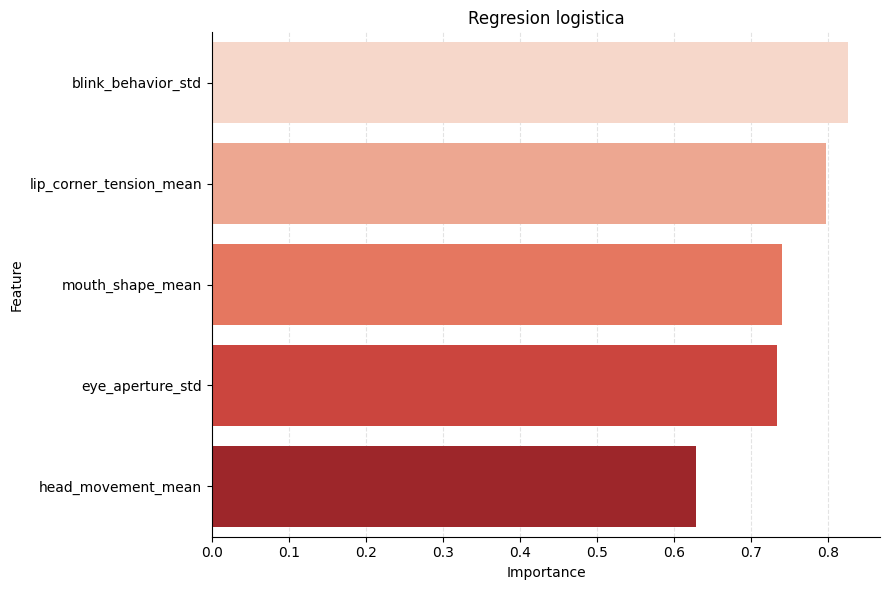

In [16]:
model = models["Logistic Regression"]
model.fit(X_train, y_train)

coefs = model.named_steps["logisticregression"].coef_[0]

coef_df_log = pd.DataFrame({
    "feature": X_train.columns,
    "coef": coefs
}).sort_values("coef", ascending=False)

print(coef_df_log.head(5))
print(coef_df_log.tail(5))
plot_feature_importance(coef_df_log, top_n=5, title = 'Regresion logistica')

## Random Forest:

                feature      coef
3   blink_behavior_mean  0.083524
4    blink_behavior_std  0.075888
7      eye_aperture_std  0.071515
13   gaze_stability_std  0.068502
18     mouth_shape_mean  0.064590
                   feature      coef
22        lip_pressing_std  0.010054
5       blink_behavior_max  0.009227
26  lip_corner_tension_max  0.006339
2        head_movement_max  0.005811
23        lip_pressing_max  0.003113


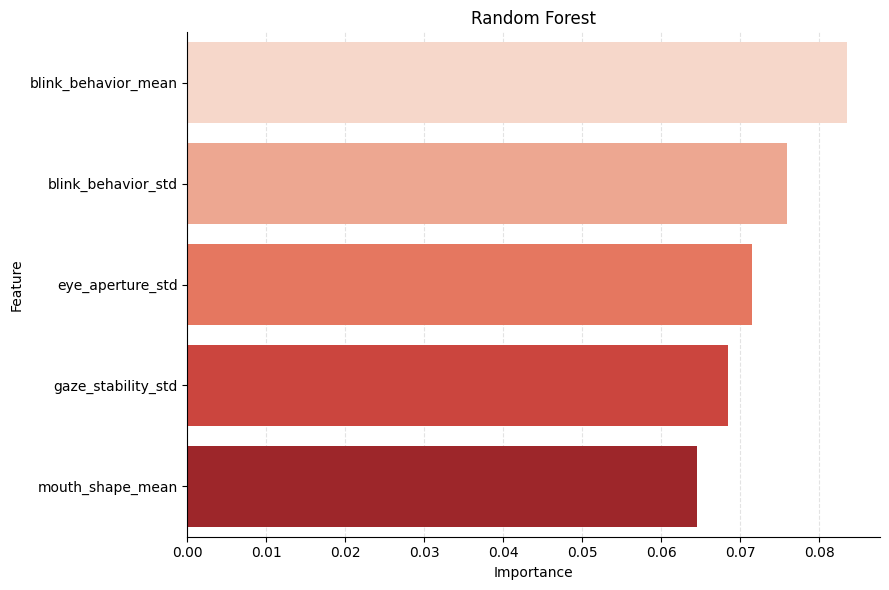

In [17]:
rf = models["Random Forest"]
rf.fit(X_train, y_train)

coefs = rf.feature_importances_

coef_df_rf = pd.DataFrame({
    "feature": X_train.columns,
    "coef": coefs
}).sort_values("coef", ascending=False)


print(coef_df_rf.head(5))
print(coef_df_rf.tail(5))
plot_feature_importance(coef_df_rf, top_n=5, title = 'Random Forest')

## Balanced Random Forest:

                feature      coef
4    blink_behavior_std  0.093683
3   blink_behavior_mean  0.076349
7      eye_aperture_std  0.070386
13   gaze_stability_std  0.067088
18     mouth_shape_mean  0.065010
                   feature      coef
21       lip_pressing_mean  0.009308
26  lip_corner_tension_max  0.007517
5       blink_behavior_max  0.006683
2        head_movement_max  0.006011
23        lip_pressing_max  0.003654


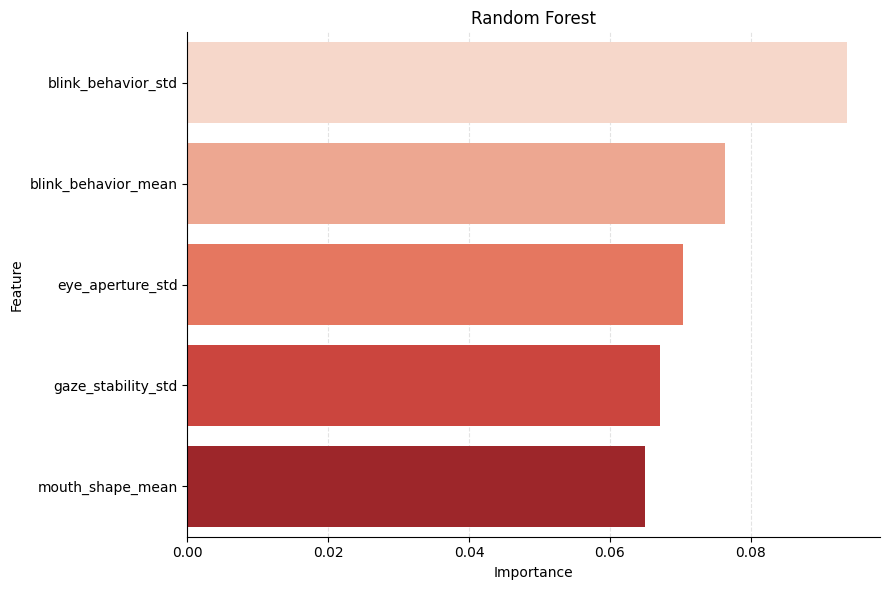

In [18]:
brf = models["Balanced Random Forest"]
brf.fit(X_train, y_train)

coefs = brf.feature_importances_

coef_df_brf = pd.DataFrame({
    "feature": X_train.columns,
    "coef": coefs
}).sort_values("coef", ascending=False)

print(coef_df_brf.head(5))
print(coef_df_brf.tail(5))
plot_feature_importance(coef_df_brf, top_n=5, title = 'Random Forest')

## XGBoost:

                   feature      coef
26  lip_corner_tension_max  0.096292
4       blink_behavior_std  0.084432
16    eyebrow_movement_std  0.055809
28   jaw_mouth_tension_std  0.053888
21       lip_pressing_mean  0.053453
                  feature      coef
14     gaze_stability_max  0.006046
2       head_movement_max  0.000000
5      blink_behavior_max  0.000000
23       lip_pressing_max  0.000000
29  jaw_mouth_tension_max  0.000000


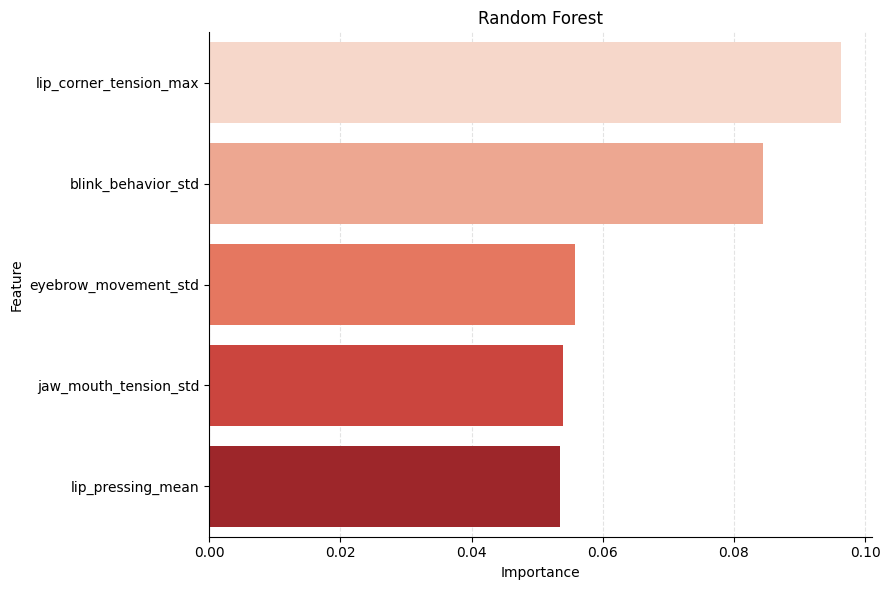

In [19]:
xgb_model = models["XGBoost"]
xgb_model.fit(X_train, y_train)

coefs = xgb_model.feature_importances_

coef_df_xgb = pd.DataFrame({
    "feature": X_train.columns,
    "coef": coefs
}).sort_values("coef", ascending=False)

print(coef_df_xgb.head(5))
print(coef_df_xgb.tail(5))
plot_feature_importance(coef_df_xgb, top_n=5, title = 'Random Forest')

## Window level prediction, Task level aggregation

In [22]:

cue_df = pd.read_csv("../results/Qwen3_VL_4B_Instruct_visual_cues_5s5fps_cropped_results.csv")

CUE_COLS = [
    "head_movement",
    "blink_behavior",
    "eye_aperture",
    "gaze_direction",
    "gaze_stability",
    "eyebrow_movement",
    "mouth_shape",
    "lip_pressing",
    "lip_corner_tension",
    "jaw_mouth_tension",
    "visual_confidence"
]

cue_df["subject_activity"] = (
    cue_df["subject"].astype(str) + "_" + cue_df["activity"].astype(str)
)

cue_df[CUE_COLS] = cue_df[CUE_COLS].apply(pd.to_numeric, errors="coerce")
cue_df = cue_df.dropna(subset=CUE_COLS)
cue_df = cue_df[(cue_df[CUE_COLS] >= 0).all(axis=1)]


#Merge task-level labels onto each window
df = cue_df.merge(gt, left_on="subject_activity", right_on='subject/task', how="inner")

X = df[CUE_COLS]
y = df["binary-stress"].astype(int)
groups_subject = df["subject"]

# Used later for task-level aggregation
task_ids = df["subject_activity"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

train_idx, test_idx = next(
    sgkf.split(X, y, groups_subject)
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

groups_train = groups_subject.iloc[train_idx]

task_train = task_ids.iloc[train_idx]
task_test = task_ids.iloc[test_idx]

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()


#models
models = {
    "Logistic Regression": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    ),

    "Random Forest":
        RandomForestClassifier(
            class_weight="balanced",
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1
    ),

    "Balanced Random Forest": make_pipeline(
        SimpleImputer(strategy="median"),
        BalancedRandomForestClassifier(
            n_estimators=300,
            sampling_strategy="auto",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),

    "XGBoost": make_pipeline(
        SimpleImputer(strategy="median"),
        XGBClassifier(
            scale_pos_weight=scale_weight,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
}


#Task level aggregation strategies
agg_strategies = {
    "Mean": "mean",
    "Median": "median",
    "Max": "max",
    "75th_Percentile": lambda x: np.percentile(x, 75)
}


cv_train = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

results_list = []


for model_name, model in models.items():

    model.fit(X_train, y_train)

    test_probs = model.predict_proba(X_test)[:, 1]

    train_unbiased_probs = cross_val_predict(
        model,
        X_train,
        y_train,
        groups=groups_train,
        cv=cv_train,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    train_base_df = pd.DataFrame({
        "subject_activity": task_train.values,
        "true_label": y_train.values,
        "pred_prob": train_unbiased_probs
    })

    test_base_df = pd.DataFrame({
        "subject_activity": task_test.values,
        "true_label": y_test.values,
        "pred_prob": test_probs
    })

    for strategy_name, agg_func in agg_strategies.items():

        train_agg = train_base_df.groupby("subject_activity").agg(
            true_label=("true_label", "first"),
            agg_prob=("pred_prob", agg_func)
        ).reset_index()

        best_thresh = 0.5
        best_b_acc = 0

        for thresh in np.arange(0.1, 0.9, 0.02):
            train_preds = (train_agg["agg_prob"] >= thresh).astype(int)

            b_acc = balanced_accuracy_score(
                train_agg["true_label"],
                train_preds
            )

            if b_acc >= best_b_acc:
                best_b_acc = b_acc
                best_thresh = thresh

        test_agg = test_base_df.groupby("subject_activity").agg(
            true_label=("true_label", "first"),
            agg_prob=("pred_prob", agg_func)
        ).reset_index()

        test_preds = (test_agg["agg_prob"] >= best_thresh).astype(int)

        final_b_acc = balanced_accuracy_score(
            test_agg["true_label"],
            test_preds
        )
        acc = accuracy_score(test_agg["true_label"], test_preds)
        f1 = f1_score(test_agg["true_label"], test_preds)

        recall_0 = recall_score(
            test_agg["true_label"],
            test_preds,
            pos_label=0,
            zero_division=0
        )

        recall_1 = recall_score(
            test_agg["true_label"],
            test_preds,
            pos_label=1,
            zero_division=0
        )

        results_list.append({
            "Model": model_name,
            "Strategy": strategy_name,
            "Thresh": round(best_thresh, 2),
            "Bal_Acc": round(final_b_acc, 4),
            "Accuracy": round(acc, 2),
            "F1": round(f1, 2),
            "Rec_NoStress": round(recall_0, 2),
            "Rec_Stress": round(recall_1, 2),
            "N_Test_Tasks": test_agg["subject_activity"].nunique()
        })


comparison_df = (
    pd.DataFrame(results_list)
    .sort_values(by="Bal_Acc", ascending=False)
    .reset_index(drop=True)
)

print(comparison_df.to_string(index=False))

                 Model        Strategy  Thresh  Bal_Acc  Accuracy   F1  Rec_NoStress  Rec_Stress  N_Test_Tasks
Balanced Random Forest            Mean    0.48   0.7523      0.75 0.77          0.77        0.74           120
Balanced Random Forest          Median    0.46   0.7483      0.76 0.79          0.67        0.82           120
         Random Forest            Mean    0.48   0.7398      0.73 0.75          0.79        0.69           120
Balanced Random Forest 75th_Percentile    0.56   0.7245      0.71 0.70          0.85        0.60           120
         Random Forest          Median    0.48   0.7206      0.72 0.73          0.75        0.69           120
               XGBoost          Median    0.48   0.7110      0.71 0.73          0.73        0.69           120
               XGBoost            Mean    0.46   0.7025      0.72 0.76          0.60        0.81           120
         Random Forest 75th_Percentile    0.54   0.6957      0.68 0.68          0.79        0.60           120
 